In [1]:
# ============================================================
# Notebook 05 — Prophet Modelling
# Baseline V1: Default settings, yearly seasonality
# Reference: Taylor & Letham (2018)
# Implementation: Meta Prophet library
# Author: Nihaar Raut | 001309432
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import logging
logging.getLogger('prophet').setLevel(logging.ERROR)
import warnings
warnings.filterwarnings('ignore')

PROCESSED = Path('../data/processed')
FIGURES = Path('../outputs/figures')

# Load all four series
ndvi_amazon_train = pd.read_csv(PROCESSED / 'ndvi_amazon_train.csv', parse_dates=['date'])
ndvi_amazon_test = pd.read_csv(PROCESSED / 'ndvi_amazon_test.csv', parse_dates=['date'])

ndvi_sahel_train = pd.read_csv(PROCESSED / 'ndvi_sahel_train.csv', parse_dates=['date'])
ndvi_sahel_test = pd.read_csv(PROCESSED / 'ndvi_sahel_test.csv', parse_dates=['date'])

sst_atlantic_train = pd.read_csv(PROCESSED / 'sst_atlantic_train.csv', parse_dates=['date'])
sst_atlantic_test = pd.read_csv(PROCESSED / 'sst_atlantic_test.csv', parse_dates=['date'])

sst_indian_train = pd.read_csv(PROCESSED / 'sst_indian_train.csv', parse_dates=['date'])
sst_indian_test = pd.read_csv(PROCESSED / 'sst_indian_test.csv', parse_dates=['date'])

print("All series loaded successfully")

Importing plotly failed. Interactive plots will not work.


All series loaded successfully


01:55:16 - cmdstanpy - INFO - Chain [1] start processing
01:55:17 - cmdstanpy - INFO - Chain [1] done processing


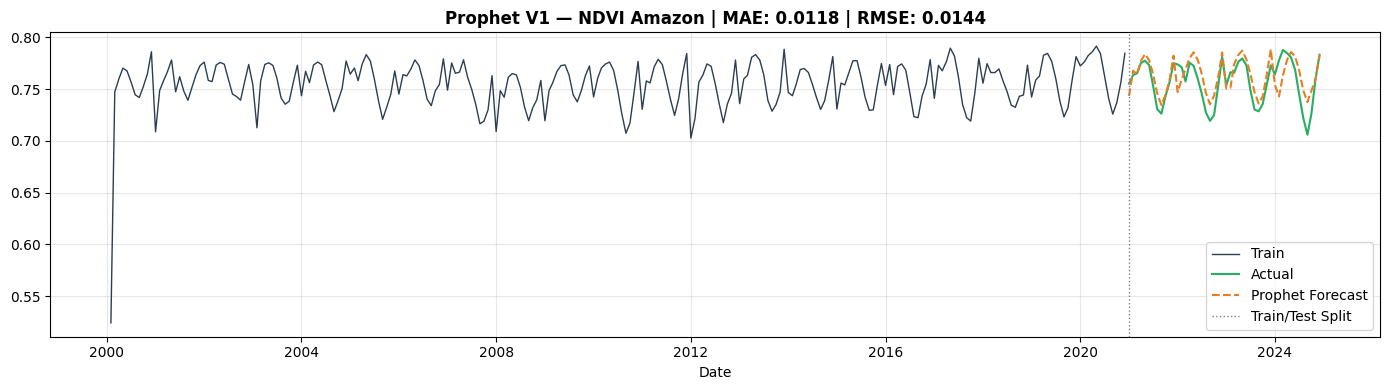

01:55:18 - cmdstanpy - INFO - Chain [1] start processing
01:55:18 - cmdstanpy - INFO - Chain [1] done processing


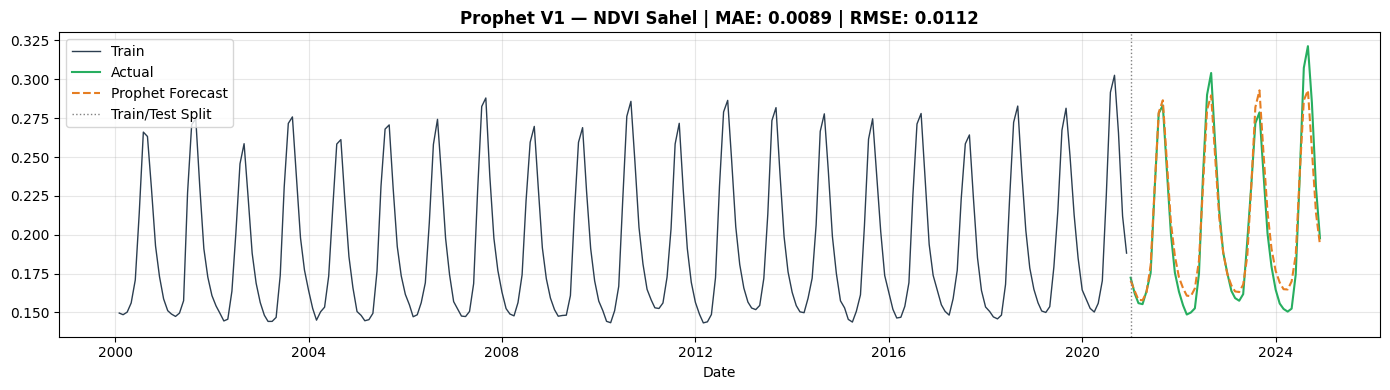

01:55:18 - cmdstanpy - INFO - Chain [1] start processing
01:55:18 - cmdstanpy - INFO - Chain [1] done processing


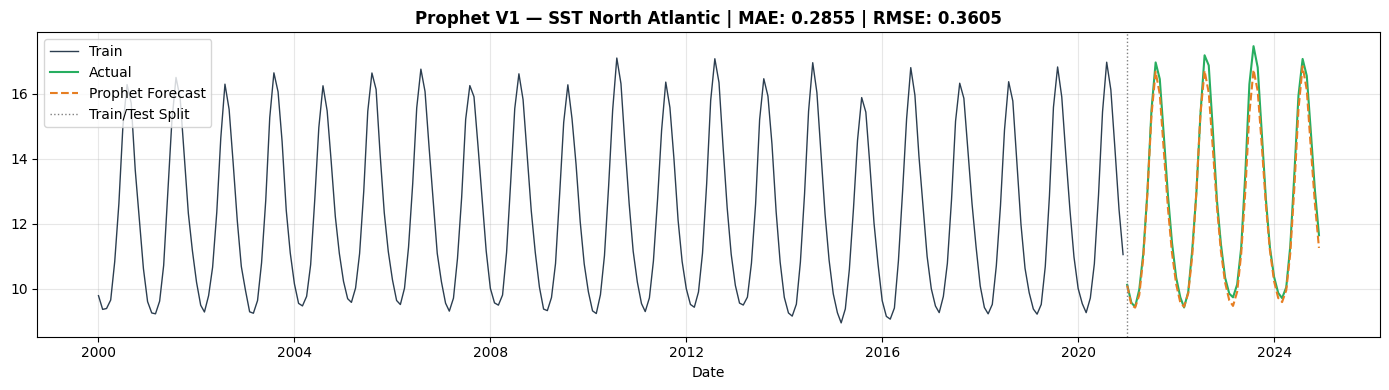

01:55:19 - cmdstanpy - INFO - Chain [1] start processing
01:55:19 - cmdstanpy - INFO - Chain [1] done processing


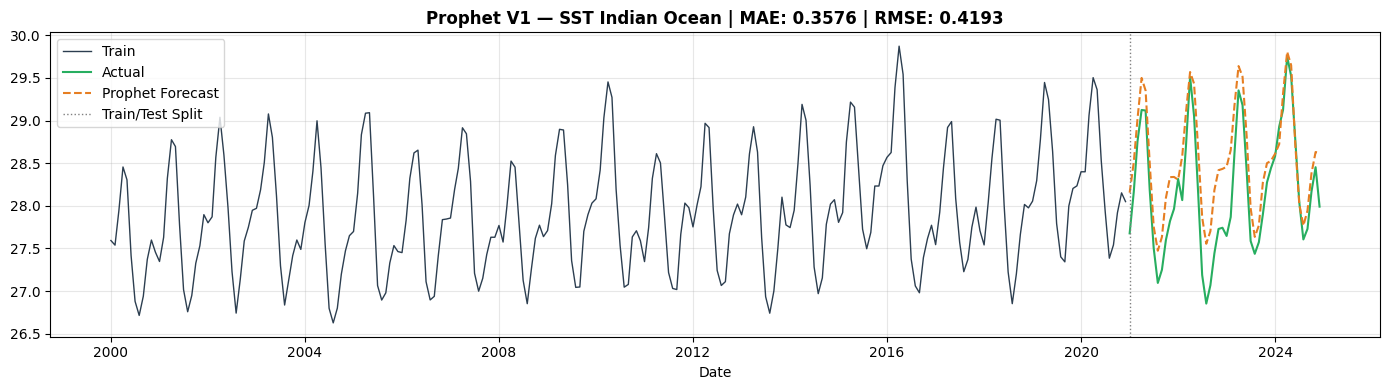


=== Prophet V1 Baseline Results ===
            series    MAE   RMSE
       NDVI Amazon 0.0118 0.0144
        NDVI Sahel 0.0089 0.0112
SST North Atlantic 0.2855 0.3605
  SST Indian Ocean 0.3576 0.4193


In [2]:
# ============================================================
# Prophet V1 — Baseline, default settings, yearly seasonality
# Prophet requires columns named 'ds' (date) and 'y' (value)
# Additive mode, yearly seasonality enabled
# ============================================================

def run_prophet(train, test, value_col, series_name):
    # Prophet requires ds/y format
    train_prophet = train[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'})
    test_prophet = test[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'})
    
    # Fit model
    model = Prophet(
        seasonality_mode='additive',
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )
    model.fit(train_prophet)
    
    # Forecast
    future = model.make_future_dataframe(periods=len(test), freq='MS')
    forecast = model.predict(future)
    forecast_test = forecast.tail(len(test))['yhat'].values
    actual = test[value_col].values
    
    # Metrics
    mae = mean_absolute_error(actual, forecast_test)
    rmse = np.sqrt(mean_squared_error(actual, forecast_test))
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['date'], train[value_col],
            color='#2c3e50', linewidth=1, label='Train')
    ax.plot(test['date'], actual,
            color='#27ae60', linewidth=1.5, label='Actual')
    ax.plot(test['date'], forecast_test,
            color='#e67e22', linewidth=1.5, linestyle='--', label='Prophet Forecast')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test Split')
    ax.set_title(f'Prophet V1 — {series_name} | MAE: {mae:.4f} | RMSE: {rmse:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    filename = f"fig_prophet_v1_{series_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    return {'series': series_name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4)}

# Run V1 on all four series
results = []

results.append(run_prophet(ndvi_amazon_train, ndvi_amazon_test,
                            'ndvi_mean', 'NDVI Amazon'))

results.append(run_prophet(ndvi_sahel_train, ndvi_sahel_test,
                            'ndvi_mean', 'NDVI Sahel'))

results.append(run_prophet(sst_atlantic_train, sst_atlantic_test,
                            'sst_mean', 'SST North Atlantic'))

results.append(run_prophet(sst_indian_train, sst_indian_test,
                            'sst_mean', 'SST Indian Ocean'))

# Results table
results_df = pd.DataFrame(results)
print("\n=== Prophet V1 Baseline Results ===")
print(results_df.to_string(index=False))

01:55:31 - cmdstanpy - INFO - Chain [1] start processing
01:55:31 - cmdstanpy - INFO - Chain [1] done processing



Fitting Prophet V2 for NDVI Amazon...

  Tuning Prophet for NDVI Amazon...


  0%|          | 0/10 [00:00<?, ?it/s]

01:55:31 - cmdstanpy - INFO - Chain [1] start processing
01:55:32 - cmdstanpy - INFO - Chain [1] done processing
01:55:32 - cmdstanpy - INFO - Chain [1] start processing
01:55:32 - cmdstanpy - INFO - Chain [1] done processing
01:55:32 - cmdstanpy - INFO - Chain [1] start processing
01:55:32 - cmdstanpy - INFO - Chain [1] done processing
01:55:32 - cmdstanpy - INFO - Chain [1] start processing
01:55:32 - cmdstanpy - INFO - Chain [1] done processing
01:55:32 - cmdstanpy - INFO - Chain [1] start processing
01:55:32 - cmdstanpy - INFO - Chain [1] done processing
01:55:33 - cmdstanpy - INFO - Chain [1] start processing
01:55:33 - cmdstanpy - INFO - Chain [1] done processing
01:55:33 - cmdstanpy - INFO - Chain [1] start processing
01:55:33 - cmdstanpy - INFO - Chain [1] done processing
01:55:33 - cmdstanpy - INFO - Chain [1] start processing
01:55:33 - cmdstanpy - INFO - Chain [1] done processing
01:55:33 - cmdstanpy - INFO - Chain [1] start processing
01:55:33 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

01:56:08 - cmdstanpy - INFO - Chain [1] start processing
01:56:08 - cmdstanpy - INFO - Chain [1] done processing
01:56:09 - cmdstanpy - INFO - Chain [1] start processing
01:56:09 - cmdstanpy - INFO - Chain [1] done processing
01:56:09 - cmdstanpy - INFO - Chain [1] start processing
01:56:09 - cmdstanpy - INFO - Chain [1] done processing
01:56:09 - cmdstanpy - INFO - Chain [1] start processing
01:56:09 - cmdstanpy - INFO - Chain [1] done processing
01:56:09 - cmdstanpy - INFO - Chain [1] start processing
01:56:09 - cmdstanpy - INFO - Chain [1] done processing
01:56:10 - cmdstanpy - INFO - Chain [1] start processing
01:56:10 - cmdstanpy - INFO - Chain [1] done processing
01:56:10 - cmdstanpy - INFO - Chain [1] start processing
01:56:10 - cmdstanpy - INFO - Chain [1] done processing
01:56:10 - cmdstanpy - INFO - Chain [1] start processing
01:56:10 - cmdstanpy - INFO - Chain [1] done processing
01:56:10 - cmdstanpy - INFO - Chain [1] start processing
01:56:11 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

01:56:11 - cmdstanpy - INFO - Chain [1] start processing
01:56:11 - cmdstanpy - INFO - Chain [1] done processing
01:56:12 - cmdstanpy - INFO - Chain [1] start processing
01:56:12 - cmdstanpy - INFO - Chain [1] done processing
01:56:12 - cmdstanpy - INFO - Chain [1] start processing
01:56:12 - cmdstanpy - INFO - Chain [1] done processing
01:56:12 - cmdstanpy - INFO - Chain [1] start processing
01:56:12 - cmdstanpy - INFO - Chain [1] done processing
01:56:12 - cmdstanpy - INFO - Chain [1] start processing
01:56:13 - cmdstanpy - INFO - Chain [1] done processing
01:56:13 - cmdstanpy - INFO - Chain [1] start processing
01:56:13 - cmdstanpy - INFO - Chain [1] done processing
01:56:13 - cmdstanpy - INFO - Chain [1] start processing
01:56:13 - cmdstanpy - INFO - Chain [1] done processing
01:56:13 - cmdstanpy - INFO - Chain [1] start processing
01:56:13 - cmdstanpy - INFO - Chain [1] done processing
01:56:14 - cmdstanpy - INFO - Chain [1] start processing
01:56:14 - cmdstanpy - INFO - Chain [1]

  Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 20.0} | CV MAE: 0.0084


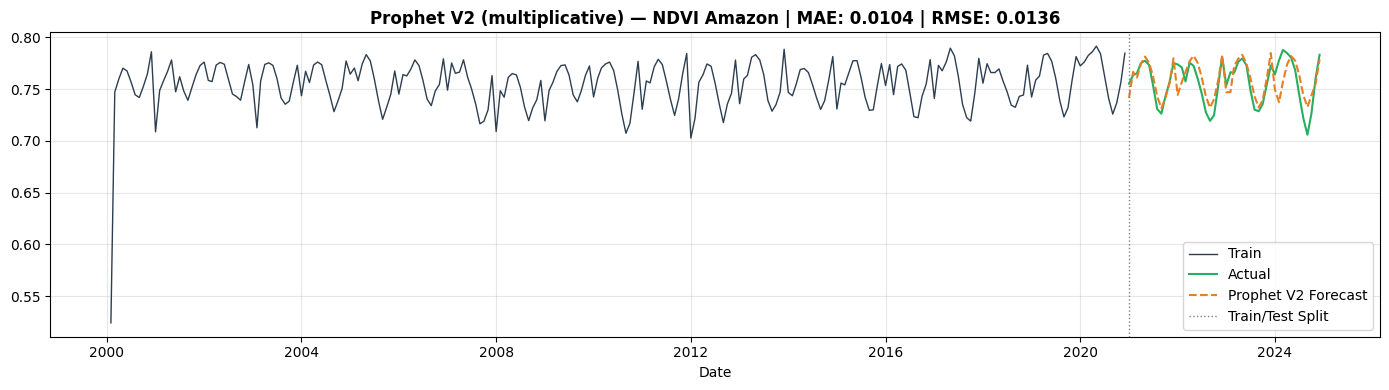

01:56:15 - cmdstanpy - INFO - Chain [1] start processing
01:56:15 - cmdstanpy - INFO - Chain [1] done processing



Fitting Prophet V2 for NDVI Sahel...

  Tuning Prophet for NDVI Sahel...


  0%|          | 0/10 [00:00<?, ?it/s]

01:56:15 - cmdstanpy - INFO - Chain [1] start processing
01:56:15 - cmdstanpy - INFO - Chain [1] done processing
01:56:15 - cmdstanpy - INFO - Chain [1] start processing
01:56:15 - cmdstanpy - INFO - Chain [1] done processing
01:56:15 - cmdstanpy - INFO - Chain [1] start processing
01:56:15 - cmdstanpy - INFO - Chain [1] done processing
01:56:16 - cmdstanpy - INFO - Chain [1] start processing
01:56:16 - cmdstanpy - INFO - Chain [1] done processing
01:56:16 - cmdstanpy - INFO - Chain [1] start processing
01:56:16 - cmdstanpy - INFO - Chain [1] done processing
01:56:16 - cmdstanpy - INFO - Chain [1] start processing
01:56:16 - cmdstanpy - INFO - Chain [1] done processing
01:56:16 - cmdstanpy - INFO - Chain [1] start processing
01:56:16 - cmdstanpy - INFO - Chain [1] done processing
01:56:17 - cmdstanpy - INFO - Chain [1] start processing
01:56:17 - cmdstanpy - INFO - Chain [1] done processing
01:56:17 - cmdstanpy - INFO - Chain [1] start processing
01:56:17 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

01:56:51 - cmdstanpy - INFO - Chain [1] start processing
01:56:51 - cmdstanpy - INFO - Chain [1] done processing
01:56:51 - cmdstanpy - INFO - Chain [1] start processing
01:56:51 - cmdstanpy - INFO - Chain [1] done processing
01:56:51 - cmdstanpy - INFO - Chain [1] start processing
01:56:51 - cmdstanpy - INFO - Chain [1] done processing
01:56:52 - cmdstanpy - INFO - Chain [1] start processing
01:56:52 - cmdstanpy - INFO - Chain [1] done processing
01:56:52 - cmdstanpy - INFO - Chain [1] start processing
01:56:52 - cmdstanpy - INFO - Chain [1] done processing
01:56:52 - cmdstanpy - INFO - Chain [1] start processing
01:56:52 - cmdstanpy - INFO - Chain [1] done processing
01:56:52 - cmdstanpy - INFO - Chain [1] start processing
01:56:52 - cmdstanpy - INFO - Chain [1] done processing
01:56:53 - cmdstanpy - INFO - Chain [1] start processing
01:56:53 - cmdstanpy - INFO - Chain [1] done processing
01:56:53 - cmdstanpy - INFO - Chain [1] start processing
01:56:53 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

01:56:54 - cmdstanpy - INFO - Chain [1] start processing
01:56:54 - cmdstanpy - INFO - Chain [1] done processing
01:56:54 - cmdstanpy - INFO - Chain [1] start processing
01:56:54 - cmdstanpy - INFO - Chain [1] done processing
01:56:54 - cmdstanpy - INFO - Chain [1] start processing
01:56:54 - cmdstanpy - INFO - Chain [1] done processing
01:56:54 - cmdstanpy - INFO - Chain [1] start processing
01:56:54 - cmdstanpy - INFO - Chain [1] done processing
01:56:55 - cmdstanpy - INFO - Chain [1] start processing
01:56:55 - cmdstanpy - INFO - Chain [1] done processing
01:56:55 - cmdstanpy - INFO - Chain [1] start processing
01:56:55 - cmdstanpy - INFO - Chain [1] done processing
01:56:55 - cmdstanpy - INFO - Chain [1] start processing
01:56:55 - cmdstanpy - INFO - Chain [1] done processing
01:56:55 - cmdstanpy - INFO - Chain [1] start processing
01:56:55 - cmdstanpy - INFO - Chain [1] done processing
01:56:56 - cmdstanpy - INFO - Chain [1] start processing
01:56:56 - cmdstanpy - INFO - Chain [1]

  Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0} | CV MAE: 0.0054


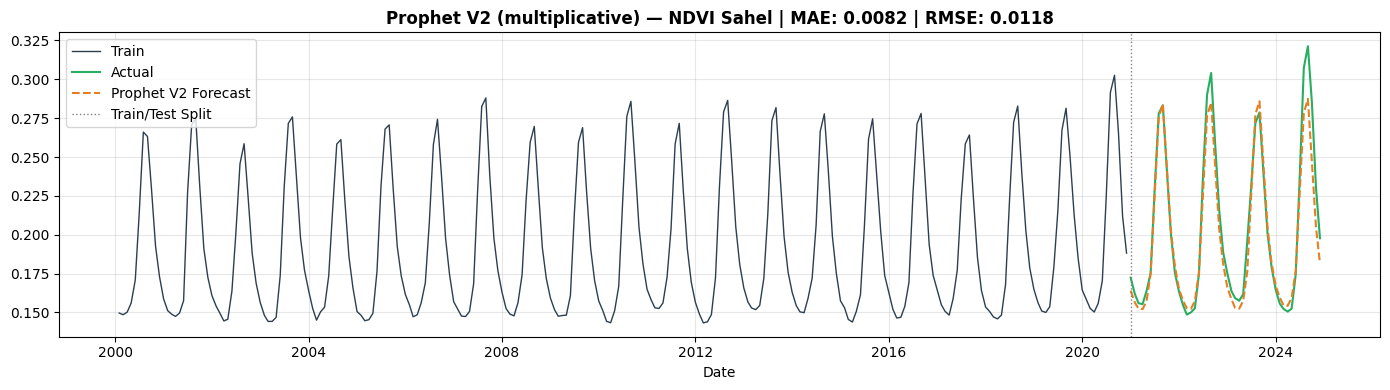

01:56:57 - cmdstanpy - INFO - Chain [1] start processing
01:56:57 - cmdstanpy - INFO - Chain [1] done processing



Fitting Prophet V2 for SST North Atlantic...

  Tuning Prophet for SST North Atlantic...


  0%|          | 0/10 [00:00<?, ?it/s]

01:56:57 - cmdstanpy - INFO - Chain [1] start processing
01:56:57 - cmdstanpy - INFO - Chain [1] done processing
01:56:57 - cmdstanpy - INFO - Chain [1] start processing
01:56:57 - cmdstanpy - INFO - Chain [1] done processing
01:56:57 - cmdstanpy - INFO - Chain [1] start processing
01:56:57 - cmdstanpy - INFO - Chain [1] done processing
01:56:57 - cmdstanpy - INFO - Chain [1] start processing
01:56:58 - cmdstanpy - INFO - Chain [1] done processing
01:56:58 - cmdstanpy - INFO - Chain [1] start processing
01:56:58 - cmdstanpy - INFO - Chain [1] done processing
01:56:58 - cmdstanpy - INFO - Chain [1] start processing
01:56:58 - cmdstanpy - INFO - Chain [1] done processing
01:56:58 - cmdstanpy - INFO - Chain [1] start processing
01:56:58 - cmdstanpy - INFO - Chain [1] done processing
01:56:58 - cmdstanpy - INFO - Chain [1] start processing
01:56:58 - cmdstanpy - INFO - Chain [1] done processing
01:56:59 - cmdstanpy - INFO - Chain [1] start processing
01:56:59 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

01:57:33 - cmdstanpy - INFO - Chain [1] start processing
01:57:33 - cmdstanpy - INFO - Chain [1] done processing
01:57:34 - cmdstanpy - INFO - Chain [1] start processing
01:57:34 - cmdstanpy - INFO - Chain [1] done processing
01:57:34 - cmdstanpy - INFO - Chain [1] start processing
01:57:34 - cmdstanpy - INFO - Chain [1] done processing
01:57:34 - cmdstanpy - INFO - Chain [1] start processing
01:57:34 - cmdstanpy - INFO - Chain [1] done processing
01:57:34 - cmdstanpy - INFO - Chain [1] start processing
01:57:35 - cmdstanpy - INFO - Chain [1] done processing
01:57:35 - cmdstanpy - INFO - Chain [1] start processing
01:57:35 - cmdstanpy - INFO - Chain [1] done processing
01:57:35 - cmdstanpy - INFO - Chain [1] start processing
01:57:35 - cmdstanpy - INFO - Chain [1] done processing
01:57:35 - cmdstanpy - INFO - Chain [1] start processing
01:57:36 - cmdstanpy - INFO - Chain [1] done processing
01:57:36 - cmdstanpy - INFO - Chain [1] start processing
01:57:36 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

01:57:37 - cmdstanpy - INFO - Chain [1] start processing
01:57:37 - cmdstanpy - INFO - Chain [1] done processing
01:57:37 - cmdstanpy - INFO - Chain [1] start processing
01:57:37 - cmdstanpy - INFO - Chain [1] done processing
01:57:37 - cmdstanpy - INFO - Chain [1] start processing
01:57:37 - cmdstanpy - INFO - Chain [1] done processing
01:57:38 - cmdstanpy - INFO - Chain [1] start processing
01:57:38 - cmdstanpy - INFO - Chain [1] done processing
01:57:38 - cmdstanpy - INFO - Chain [1] start processing
01:57:38 - cmdstanpy - INFO - Chain [1] done processing
01:57:38 - cmdstanpy - INFO - Chain [1] start processing
01:57:38 - cmdstanpy - INFO - Chain [1] done processing
01:57:38 - cmdstanpy - INFO - Chain [1] start processing
01:57:39 - cmdstanpy - INFO - Chain [1] done processing
01:57:39 - cmdstanpy - INFO - Chain [1] start processing
01:57:39 - cmdstanpy - INFO - Chain [1] done processing
01:57:39 - cmdstanpy - INFO - Chain [1] start processing
01:57:39 - cmdstanpy - INFO - Chain [1]

  Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0} | CV MAE: 0.2149


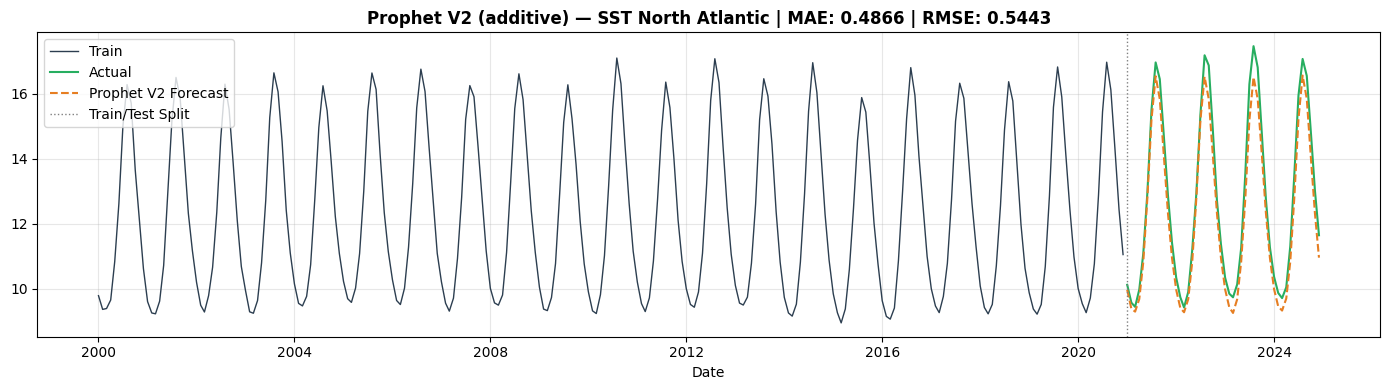

01:57:40 - cmdstanpy - INFO - Chain [1] start processing
01:57:40 - cmdstanpy - INFO - Chain [1] done processing



Fitting Prophet V2 for SST Indian Ocean...

  Tuning Prophet for SST Indian Ocean...


  0%|          | 0/10 [00:00<?, ?it/s]

01:57:41 - cmdstanpy - INFO - Chain [1] start processing
01:57:41 - cmdstanpy - INFO - Chain [1] done processing
01:57:41 - cmdstanpy - INFO - Chain [1] start processing
01:57:41 - cmdstanpy - INFO - Chain [1] done processing
01:57:41 - cmdstanpy - INFO - Chain [1] start processing
01:57:41 - cmdstanpy - INFO - Chain [1] done processing
01:57:41 - cmdstanpy - INFO - Chain [1] start processing
01:57:41 - cmdstanpy - INFO - Chain [1] done processing
01:57:42 - cmdstanpy - INFO - Chain [1] start processing
01:57:42 - cmdstanpy - INFO - Chain [1] done processing
01:57:42 - cmdstanpy - INFO - Chain [1] start processing
01:57:42 - cmdstanpy - INFO - Chain [1] done processing
01:57:42 - cmdstanpy - INFO - Chain [1] start processing
01:57:42 - cmdstanpy - INFO - Chain [1] done processing
01:57:42 - cmdstanpy - INFO - Chain [1] start processing
01:57:42 - cmdstanpy - INFO - Chain [1] done processing
01:57:43 - cmdstanpy - INFO - Chain [1] start processing
01:57:43 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

01:58:20 - cmdstanpy - INFO - Chain [1] start processing
01:58:21 - cmdstanpy - INFO - Chain [1] done processing
01:58:21 - cmdstanpy - INFO - Chain [1] start processing
01:58:21 - cmdstanpy - INFO - Chain [1] done processing
01:58:21 - cmdstanpy - INFO - Chain [1] start processing
01:58:21 - cmdstanpy - INFO - Chain [1] done processing
01:58:21 - cmdstanpy - INFO - Chain [1] start processing
01:58:21 - cmdstanpy - INFO - Chain [1] done processing
01:58:22 - cmdstanpy - INFO - Chain [1] start processing
01:58:22 - cmdstanpy - INFO - Chain [1] done processing
01:58:22 - cmdstanpy - INFO - Chain [1] start processing
01:58:22 - cmdstanpy - INFO - Chain [1] done processing
01:58:22 - cmdstanpy - INFO - Chain [1] start processing
01:58:22 - cmdstanpy - INFO - Chain [1] done processing
01:58:22 - cmdstanpy - INFO - Chain [1] start processing
01:58:23 - cmdstanpy - INFO - Chain [1] done processing
01:58:23 - cmdstanpy - INFO - Chain [1] start processing
01:58:23 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

01:58:24 - cmdstanpy - INFO - Chain [1] start processing
01:58:24 - cmdstanpy - INFO - Chain [1] done processing
01:58:24 - cmdstanpy - INFO - Chain [1] start processing
01:58:24 - cmdstanpy - INFO - Chain [1] done processing
01:58:24 - cmdstanpy - INFO - Chain [1] start processing
01:58:25 - cmdstanpy - INFO - Chain [1] done processing
01:58:25 - cmdstanpy - INFO - Chain [1] start processing
01:58:25 - cmdstanpy - INFO - Chain [1] done processing
01:58:25 - cmdstanpy - INFO - Chain [1] start processing
01:58:25 - cmdstanpy - INFO - Chain [1] done processing
01:58:25 - cmdstanpy - INFO - Chain [1] start processing
01:58:25 - cmdstanpy - INFO - Chain [1] done processing
01:58:26 - cmdstanpy - INFO - Chain [1] start processing
01:58:26 - cmdstanpy - INFO - Chain [1] done processing
01:58:26 - cmdstanpy - INFO - Chain [1] start processing
01:58:26 - cmdstanpy - INFO - Chain [1] done processing
01:58:26 - cmdstanpy - INFO - Chain [1] start processing
01:58:26 - cmdstanpy - INFO - Chain [1]

  Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0} | CV MAE: 0.2511


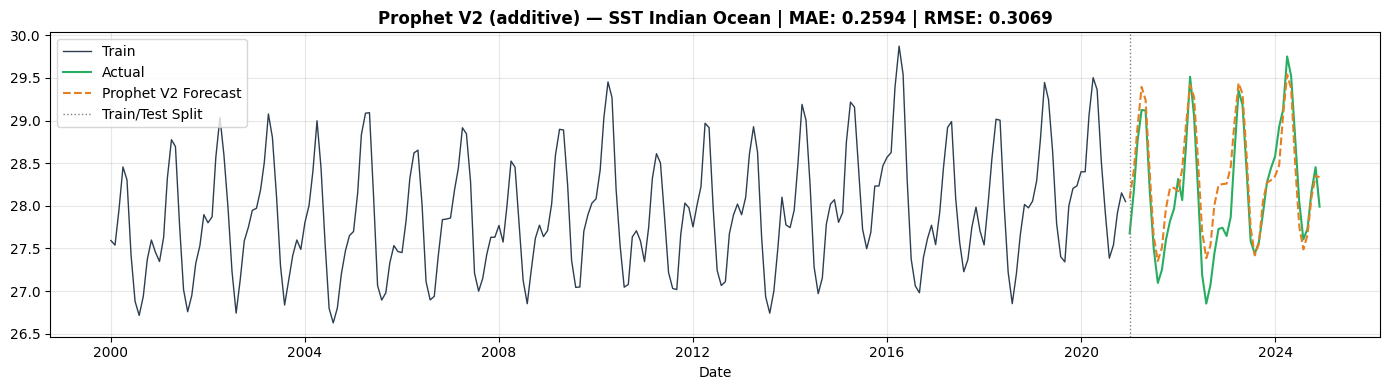


=== Prophet V2 Results ===
            series seasonality_mode  changepoint_prior_scale  seasonality_prior_scale    MAE   RMSE
       NDVI Amazon   multiplicative                     0.01                     20.0 0.0104 0.0136
        NDVI Sahel   multiplicative                     0.01                      1.0 0.0082 0.0118
SST North Atlantic         additive                     0.01                     10.0 0.4866 0.5443
  SST Indian Ocean         additive                     0.01                     10.0 0.2594 0.3069


In [3]:
# ============================================================
# Prophet V2 — Tuned hyperparameters via cross-validation
# Improvements over V1 (default settings):
#   - changepoint_prior_scale tuned (controls trend flexibility)
#   - seasonality_prior_scale tuned (controls seasonal strength)
#   - changepoint_range=0.95 (allows changepoints closer to end)
#   - multiplicative seasonality tested for NDVI series
#     (amplitude grows with level — Sahel vegetation trend)
#   - cross_validation used to select best prior scales
# Reference: Taylor & Letham (2018) Am. Statistician 72(1)
# ============================================================

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

def tune_prophet(train, value_col, series_name, seasonality_mode='additive'):
    """Use Prophet cross-validation to find best hyperparameters."""
    print(f"\n  Tuning Prophet for {series_name}...")
    
    train_prophet = train[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'})
    
    best_mae = float('inf')
    best_params = {}
    
    # Parameter grid — focused search around V1 defaults
    changepoint_scales = [0.01, 0.05, 0.1, 0.3]
    seasonality_scales = [1.0, 5.0, 10.0, 20.0]
    
    for cp_scale in changepoint_scales:
        for s_scale in seasonality_scales:
            try:
                m = Prophet(
                    changepoint_prior_scale=cp_scale,
                    seasonality_prior_scale=s_scale,
                    seasonality_mode=seasonality_mode,
                    yearly_seasonality=True,
                    weekly_seasonality=False,
                    daily_seasonality=False,
                    changepoint_range=0.95
                )
                m.fit(train_prophet)
                
                # Cross-validation: 180-day horizon, 365-day initial, 180-day period
                df_cv = cross_validation(
                    m,
                    initial='3650 days',   # ~10 years training
                    period='365 days',     # evaluate every year
                    horizon='365 days',    # 1-year forecast horizon
                    parallel=None
                )
                df_p = performance_metrics(df_cv, rolling_window=1)
                mae = df_p['mae'].mean()
                
                if mae < best_mae:
                    best_mae = mae
                    best_params = {
                        'changepoint_prior_scale': cp_scale,
                        'seasonality_prior_scale': s_scale
                    }
            except:
                continue
    
    print(f"  Best params: {best_params} | CV MAE: {best_mae:.4f}")
    return best_params

def run_prophet_v2(train, test, value_col, series_name, seasonality_mode='additive'):
    print(f"\nFitting Prophet V2 for {series_name}...")
    
    # Tune first
    best_params = tune_prophet(train, value_col, series_name, seasonality_mode)
    
    train_prophet = train[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'})
    test_prophet = test[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'})
    
    # Fit with best params
    model = Prophet(
        changepoint_prior_scale=best_params['changepoint_prior_scale'],
        seasonality_prior_scale=best_params['seasonality_prior_scale'],
        seasonality_mode=seasonality_mode,
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_range=0.95
    )
    model.fit(train_prophet)
    
    # Forecast
    future = model.make_future_dataframe(periods=len(test), freq='MS')
    forecast = model.predict(future)
    forecast_test = forecast.tail(len(test))['yhat'].values
    actual = test[value_col].values
    
    # Metrics
    mae = mean_absolute_error(actual, forecast_test)
    rmse = np.sqrt(mean_squared_error(actual, forecast_test))
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['date'], train[value_col],
            color='#2c3e50', linewidth=1, label='Train')
    ax.plot(test['date'], actual,
            color='#27ae60', linewidth=1.5, label='Actual')
    ax.plot(test['date'], forecast_test,
            color='#e67e22', linewidth=1.5, linestyle='--',
            label=f'Prophet V2 Forecast')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test Split')
    ax.set_title(f'Prophet V2 ({seasonality_mode}) — {series_name} | MAE: {mae:.4f} | RMSE: {rmse:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    filename = f"fig_prophet_v2_{series_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    return {
        'series': series_name,
        'seasonality_mode': seasonality_mode,
        'changepoint_prior_scale': best_params['changepoint_prior_scale'],
        'seasonality_prior_scale': best_params['seasonality_prior_scale'],
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4)
    }

# Run V2 — NDVI series use multiplicative (amplitude varies with level)
# SST series use additive (amplitude stable)
results_prophet_v2 = []

results_prophet_v2.append(run_prophet_v2(
    ndvi_amazon_train, ndvi_amazon_test,
    'ndvi_mean', 'NDVI Amazon', seasonality_mode='multiplicative'))

results_prophet_v2.append(run_prophet_v2(
    ndvi_sahel_train, ndvi_sahel_test,
    'ndvi_mean', 'NDVI Sahel', seasonality_mode='multiplicative'))

results_prophet_v2.append(run_prophet_v2(
    sst_atlantic_train, sst_atlantic_test,
    'sst_mean', 'SST North Atlantic', seasonality_mode='additive'))

results_prophet_v2.append(run_prophet_v2(
    sst_indian_train, sst_indian_test,
    'sst_mean', 'SST Indian Ocean', seasonality_mode='additive'))

# Results table
results_prophet_v2_df = pd.DataFrame(results_prophet_v2)
print("\n=== Prophet V2 Results ===")
print(results_prophet_v2_df.to_string(index=False))

01:59:06 - cmdstanpy - INFO - Chain [1] start processing



Fitting Prophet V3 for NDVI Amazon...


01:59:06 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/10 [00:00<?, ?it/s]

01:59:06 - cmdstanpy - INFO - Chain [1] start processing
01:59:06 - cmdstanpy - INFO - Chain [1] done processing
01:59:06 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
01:59:06 - cmdstanpy - INFO - Chain [1] start processing
01:59:06 - cmdstanpy - INFO - Chain [1] done processing
01:59:07 - cmdstanpy - INFO - Chain [1] start processing
01:59:07 - cmdstanpy - INFO - Chain [1] done processing
01:59:07 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
01:59:07 - cmdstanpy - INFO - Chain [1] start processing
01:59:07 - cmdstanpy - INFO - Chain [1] done processing
01:59:07 - cmdstanpy - INFO - Chain [1] start processing
01:59:07 - cmdstanpy - INFO - Chain [1] done processing
01:59:07 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
01:59:07 - cmdstanpy - INFO - Chain [1] start processing
01:59:07 - cmdstanpy - INFO - Chain [1] done processing
01:59:07 - cmdstanpy - INFO - Chain [1] start processing
01:59:07 - cmdstanpy -

...

  0%|          | 0/10 [00:00<?, ?it/s]

02:00:03 - cmdstanpy - INFO - Chain [1] start processing
02:00:03 - cmdstanpy - INFO - Chain [1] done processing
02:00:04 - cmdstanpy - INFO - Chain [1] start processing
02:00:04 - cmdstanpy - INFO - Chain [1] done processing
02:00:04 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
02:00:04 - cmdstanpy - INFO - Chain [1] start processing
02:00:04 - cmdstanpy - INFO - Chain [1] done processing
02:00:04 - cmdstanpy - INFO - Chain [1] start processing
02:00:04 - cmdstanpy - INFO - Chain [1] done processing
02:00:04 - cmdstanpy - INFO - Chain [1] start processing
02:00:04 - cmdstanpy - INFO - Chain [1] done processing
02:00:04 - cmdstanpy - INFO - Chain [1] start processing
02:00:05 - cmdstanpy - INFO - Chain [1] done processing
02:00:05 - cmdstanpy - INFO - Chain [1] start processing
02:00:05 - cmdstanpy - INFO - Chain [1] done processing
02:00:05 - cmdstanpy - INFO - Chain [1] start processing
02:00:05 - cmdstanpy - INFO - Chain [1] done processing
02:00:05 - cmds

  0%|          | 0/10 [00:00<?, ?it/s]

02:00:06 - cmdstanpy - INFO - Chain [1] start processing
02:00:06 - cmdstanpy - INFO - Chain [1] done processing
02:00:06 - cmdstanpy - INFO - Chain [1] start processing
02:00:06 - cmdstanpy - INFO - Chain [1] done processing
02:00:07 - cmdstanpy - INFO - Chain [1] start processing
02:00:07 - cmdstanpy - INFO - Chain [1] done processing
02:00:07 - cmdstanpy - INFO - Chain [1] start processing
02:00:07 - cmdstanpy - INFO - Chain [1] done processing
02:00:07 - cmdstanpy - INFO - Chain [1] start processing
02:00:07 - cmdstanpy - INFO - Chain [1] done processing
02:00:07 - cmdstanpy - INFO - Chain [1] start processing
02:00:07 - cmdstanpy - INFO - Chain [1] done processing
02:00:07 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
02:00:07 - cmdstanpy - INFO - Chain [1] start processing
02:00:08 - cmdstanpy - INFO - Chain [1] done processing
02:00:08 - cmdstanpy - INFO - Chain [1] start processing
02:00:08 - cmdstanpy - INFO - Chain [1] done processing
02:00:08 - cmds

  Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 20.0} | CV MAE: 0.0088


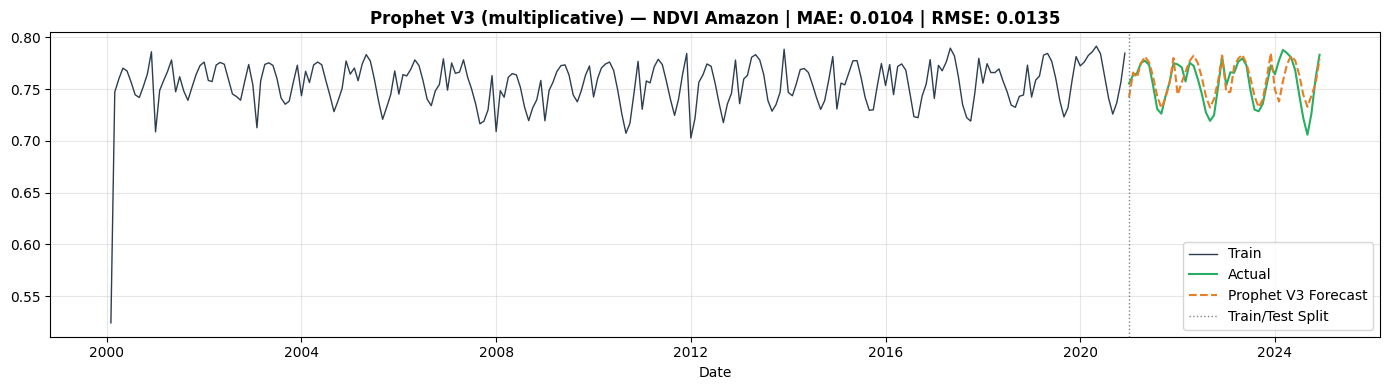

02:00:09 - cmdstanpy - INFO - Chain [1] start processing



Fitting Prophet V3 for NDVI Sahel...


02:00:09 - cmdstanpy - INFO - Chain [1] done processing
02:00:09 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
02:00:09 - cmdstanpy - INFO - Chain [1] start processing
02:00:10 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/10 [00:00<?, ?it/s]

02:00:10 - cmdstanpy - INFO - Chain [1] start processing
02:00:10 - cmdstanpy - INFO - Chain [1] done processing
02:00:10 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
02:00:10 - cmdstanpy - INFO - Chain [1] start processing
02:00:10 - cmdstanpy - INFO - Chain [1] done processing
02:00:10 - cmdstanpy - INFO - Chain [1] start processing
02:00:10 - cmdstanpy - INFO - Chain [1] done processing
02:00:10 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
02:00:10 - cmdstanpy - INFO - Chain [1] start processing
02:00:10 - cmdstanpy - INFO - Chain [1] done processing
02:00:10 - cmdstanpy - INFO - Chain [1] start processing
02:00:10 - cmdstanpy - INFO - Chain [1] done processing
02:00:10 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
02:00:10 - cmdstanpy - INFO - Chain [1] start processing
02:00:10 - cmdstanpy - INFO - Chain [1] done processing
02:00:11 - cmdstanpy - INFO - Chain [1] start processing
02:00:11 - cmdstanpy -

...

02:01:03 - cmdstanpy - INFO - Chain [1] start processing
02:01:03 - cmdstanpy - INFO - Chain [1] done processing
02:01:03 - cmdstanpy - INFO - Chain [1] start processing
02:01:03 - cmdstanpy - INFO - Chain [1] done processing
02:01:03 - cmdstanpy - INFO - Chain [1] start processing
02:01:03 - cmdstanpy - INFO - Chain [1] done processing
02:01:03 - cmdstanpy - INFO - Chain [1] start processing
02:01:03 - cmdstanpy - INFO - Chain [1] done processing
02:01:04 - cmdstanpy - INFO - Chain [1] start processing
02:01:04 - cmdstanpy - INFO - Chain [1] done processing
02:01:04 - cmdstanpy - INFO - Chain [1] start processing
02:01:04 - cmdstanpy - INFO - Chain [1] done processing
02:01:04 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
02:01:04 - cmdstanpy - INFO - Chain [1] start processing
02:01:04 - cmdstanpy - INFO - Chain [1] done processing
02:01:04 - cmdstanpy - INFO - Chain [1] start processing
02:01:04 - cmdstanpy - INFO - Chain [1] done processing
02:01:04 - cmds

  0%|          | 0/10 [00:00<?, ?it/s]

02:01:05 - cmdstanpy - INFO - Chain [1] start processing
02:01:05 - cmdstanpy - INFO - Chain [1] done processing
02:01:05 - cmdstanpy - INFO - Chain [1] start processing
02:01:05 - cmdstanpy - INFO - Chain [1] done processing
02:01:06 - cmdstanpy - INFO - Chain [1] start processing
02:01:06 - cmdstanpy - INFO - Chain [1] done processing
02:01:06 - cmdstanpy - INFO - Chain [1] start processing
02:01:06 - cmdstanpy - INFO - Chain [1] done processing
02:01:06 - cmdstanpy - INFO - Chain [1] start processing
02:01:06 - cmdstanpy - INFO - Chain [1] done processing
02:01:06 - cmdstanpy - INFO - Chain [1] start processing
02:01:06 - cmdstanpy - INFO - Chain [1] done processing
02:01:06 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
02:01:06 - cmdstanpy - INFO - Chain [1] start processing
02:01:06 - cmdstanpy - INFO - Chain [1] done processing
02:01:07 - cmdstanpy - INFO - Chain [1] start processing
02:01:07 - cmdstanpy - INFO - Chain [1] done processing
02:01:07 - cmds

  Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0} | CV MAE: 0.0053


02:01:08 - cmdstanpy - INFO - Chain [1] done processing


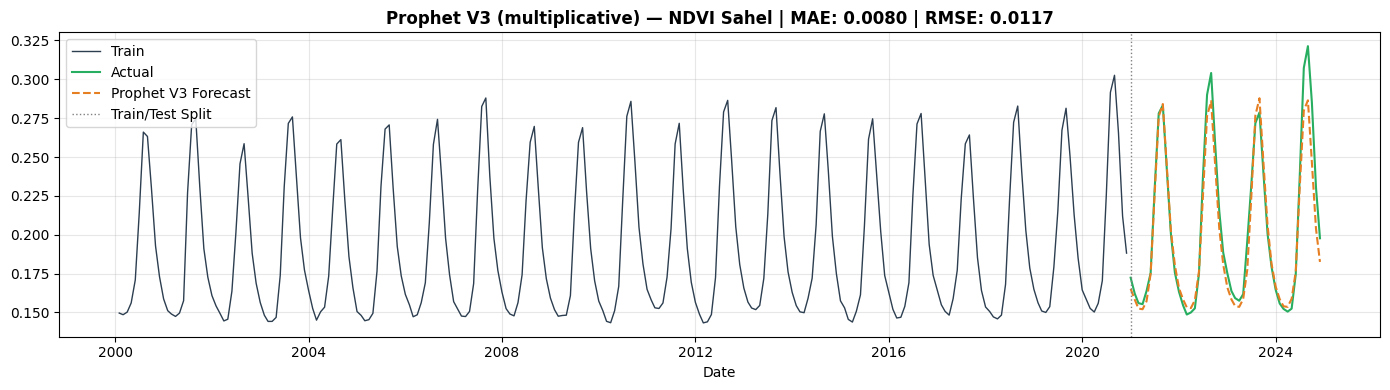

02:01:08 - cmdstanpy - INFO - Chain [1] start processing
02:01:08 - cmdstanpy - INFO - Chain [1] done processing
02:01:08 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted



Fitting Prophet V3 for SST North Atlantic...


02:01:08 - cmdstanpy - INFO - Chain [1] start processing
02:01:08 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/10 [00:00<?, ?it/s]

02:01:09 - cmdstanpy - INFO - Chain [1] start processing
02:01:09 - cmdstanpy - INFO - Chain [1] done processing
02:01:09 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
02:01:09 - cmdstanpy - INFO - Chain [1] start processing
02:01:09 - cmdstanpy - INFO - Chain [1] done processing
02:01:09 - cmdstanpy - INFO - Chain [1] start processing
02:01:09 - cmdstanpy - INFO - Chain [1] done processing
02:01:09 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
02:01:09 - cmdstanpy - INFO - Chain [1] start processing
02:01:09 - cmdstanpy - INFO - Chain [1] done processing
02:01:09 - cmdstanpy - INFO - Chain [1] start processing
02:01:09 - cmdstanpy - INFO - Chain [1] done processing
02:01:10 - cmdstanpy - INFO - Chain [1] start processing
02:01:10 - cmdstanpy - INFO - Chain [1] done processing
02:01:10 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
02:01:10 - cmdstanpy - INFO - Chain [1] start processing
02:01:10 - cmdstanpy -

...

02:02:04 - cmdstanpy - INFO - Chain [1] start processing
02:02:04 - cmdstanpy - INFO - Chain [1] done processing
02:02:04 - cmdstanpy - INFO - Chain [1] start processing
02:02:04 - cmdstanpy - INFO - Chain [1] done processing
02:02:04 - cmdstanpy - INFO - Chain [1] start processing
02:02:04 - cmdstanpy - INFO - Chain [1] done processing
02:02:04 - cmdstanpy - INFO - Chain [1] start processing
02:02:04 - cmdstanpy - INFO - Chain [1] done processing
02:02:05 - cmdstanpy - INFO - Chain [1] start processing
02:02:05 - cmdstanpy - INFO - Chain [1] done processing
02:02:05 - cmdstanpy - INFO - Chain [1] start processing
02:02:05 - cmdstanpy - INFO - Chain [1] done processing
02:02:05 - cmdstanpy - INFO - Chain [1] start processing
02:02:05 - cmdstanpy - INFO - Chain [1] done processing
02:02:05 - cmdstanpy - INFO - Chain [1] start processing
02:02:05 - cmdstanpy - INFO - Chain [1] done processing
02:02:05 - cmdstanpy - INFO - Chain [1] start processing
02:02:06 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

02:02:06 - cmdstanpy - INFO - Chain [1] start processing
02:02:06 - cmdstanpy - INFO - Chain [1] done processing
02:02:06 - cmdstanpy - INFO - Chain [1] start processing
02:02:06 - cmdstanpy - INFO - Chain [1] done processing
02:02:07 - cmdstanpy - INFO - Chain [1] start processing
02:02:07 - cmdstanpy - INFO - Chain [1] done processing
02:02:07 - cmdstanpy - INFO - Chain [1] start processing
02:02:07 - cmdstanpy - INFO - Chain [1] done processing
02:02:07 - cmdstanpy - INFO - Chain [1] start processing
02:02:07 - cmdstanpy - INFO - Chain [1] done processing
02:02:07 - cmdstanpy - INFO - Chain [1] start processing
02:02:07 - cmdstanpy - INFO - Chain [1] done processing
02:02:08 - cmdstanpy - INFO - Chain [1] start processing
02:02:08 - cmdstanpy - INFO - Chain [1] done processing
02:02:08 - cmdstanpy - INFO - Chain [1] start processing
02:02:08 - cmdstanpy - INFO - Chain [1] done processing
02:02:08 - cmdstanpy - INFO - Chain [1] start processing
02:02:08 - cmdstanpy - INFO - Chain [1]

  Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 20.0} | CV MAE: 0.2283


02:02:09 - cmdstanpy - INFO - Chain [1] done processing


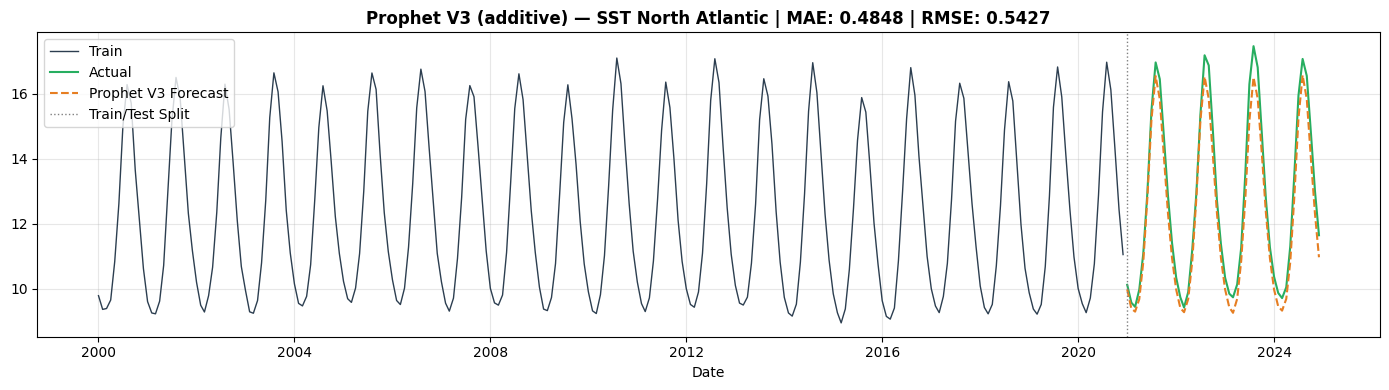

02:02:10 - cmdstanpy - INFO - Chain [1] start processing
02:02:10 - cmdstanpy - INFO - Chain [1] done processing



Fitting Prophet V3 for SST Indian Ocean...


02:02:10 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
02:02:10 - cmdstanpy - INFO - Chain [1] start processing
02:02:10 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/10 [00:00<?, ?it/s]

02:02:10 - cmdstanpy - INFO - Chain [1] start processing
02:02:10 - cmdstanpy - INFO - Chain [1] done processing
02:02:10 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
02:02:10 - cmdstanpy - INFO - Chain [1] start processing
02:02:10 - cmdstanpy - INFO - Chain [1] done processing
02:02:10 - cmdstanpy - INFO - Chain [1] start processing
02:02:10 - cmdstanpy - INFO - Chain [1] done processing
02:02:11 - cmdstanpy - INFO - Chain [1] start processing
02:02:11 - cmdstanpy - INFO - Chain [1] done processing
02:02:11 - cmdstanpy - INFO - Chain [1] start processing
02:02:11 - cmdstanpy - INFO - Chain [1] done processing
02:02:11 - cmdstanpy - INFO - Chain [1] start processing
02:02:11 - cmdstanpy - INFO - Chain [1] done processing
02:02:11 - cmdstanpy - INFO - Chain [1] start processing
02:02:11 - cmdstanpy - INFO - Chain [1] done processing
02:02:11 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
02:02:11 - cmdstanpy - INFO - Chain [1] start p

...

02:02:59 - cmdstanpy - INFO - Chain [1] start processing
02:02:59 - cmdstanpy - INFO - Chain [1] done processing
02:02:59 - cmdstanpy - INFO - Chain [1] start processing
02:02:59 - cmdstanpy - INFO - Chain [1] done processing
02:02:59 - cmdstanpy - INFO - Chain [1] start processing
02:02:59 - cmdstanpy - INFO - Chain [1] done processing
02:02:59 - cmdstanpy - INFO - Chain [1] start processing
02:02:59 - cmdstanpy - INFO - Chain [1] done processing
02:03:00 - cmdstanpy - INFO - Chain [1] start processing
02:03:00 - cmdstanpy - INFO - Chain [1] done processing
02:03:00 - cmdstanpy - INFO - Chain [1] start processing
02:03:00 - cmdstanpy - INFO - Chain [1] done processing
02:03:00 - cmdstanpy - INFO - Chain [1] start processing
02:03:00 - cmdstanpy - INFO - Chain [1] done processing
02:03:00 - cmdstanpy - INFO - Chain [1] start processing
02:03:00 - cmdstanpy - INFO - Chain [1] done processing
02:03:01 - cmdstanpy - INFO - Chain [1] start processing
02:03:01 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/10 [00:00<?, ?it/s]

02:03:01 - cmdstanpy - INFO - Chain [1] start processing
02:03:01 - cmdstanpy - INFO - Chain [1] done processing
02:03:01 - cmdstanpy - INFO - Chain [1] start processing
02:03:02 - cmdstanpy - INFO - Chain [1] done processing
02:03:02 - cmdstanpy - INFO - Chain [1] start processing
02:03:02 - cmdstanpy - INFO - Chain [1] done processing
02:03:02 - cmdstanpy - INFO - Chain [1] start processing
02:03:02 - cmdstanpy - INFO - Chain [1] done processing
02:03:02 - cmdstanpy - INFO - Chain [1] start processing
02:03:02 - cmdstanpy - INFO - Chain [1] done processing
02:03:02 - cmdstanpy - INFO - Chain [1] start processing
02:03:02 - cmdstanpy - INFO - Chain [1] done processing
02:03:03 - cmdstanpy - INFO - Chain [1] start processing
02:03:03 - cmdstanpy - INFO - Chain [1] done processing
02:03:03 - cmdstanpy - INFO - Chain [1] start processing
02:03:03 - cmdstanpy - INFO - Chain [1] done processing
02:03:03 - cmdstanpy - INFO - Chain [1] start processing
02:03:03 - cmdstanpy - INFO - Chain [1]

  Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0} | CV MAE: 0.2373


02:03:04 - cmdstanpy - INFO - Chain [1] done processing


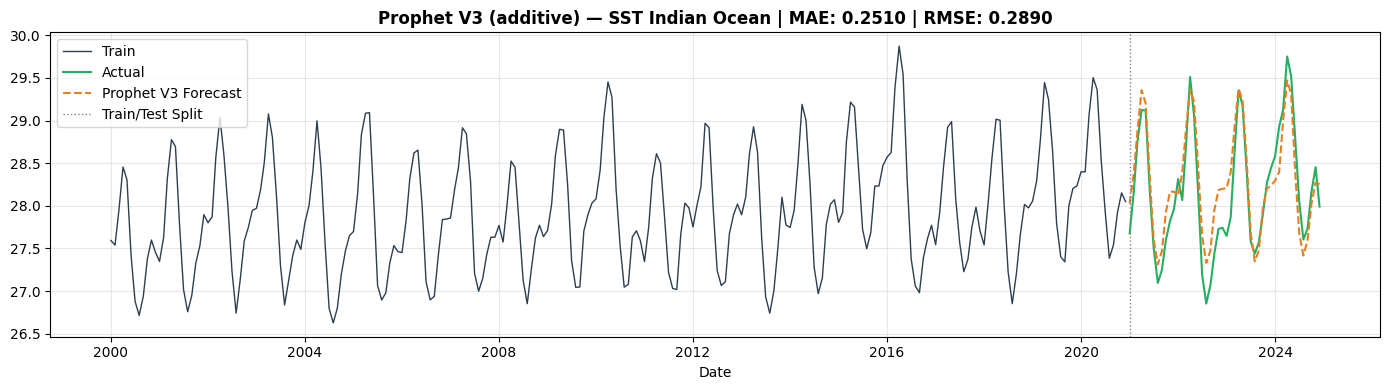


=== Prophet V3 Results ===
            series seasonality_mode  changepoint_prior_scale  seasonality_prior_scale    MAE   RMSE
       NDVI Amazon   multiplicative                     0.01                     20.0 0.0104 0.0135
        NDVI Sahel   multiplicative                     0.01                      1.0 0.0080 0.0117
SST North Atlantic         additive                     0.01                     20.0 0.4848 0.5427
  SST Indian Ocean         additive                     0.01                      1.0 0.2510 0.2890


In [4]:
# ============================================================
# Prophet V3 — Manual changepoint + wider prior scale range
# Key changes from V2 (CV-tuned, changepoint_prior=0.01):
#   - Wider search grid for changepoint_prior_scale
#   - Manual changepoints added around known climate events
#     (2010 Amazon drought, 2015-16 El Nino for SST series)
#   - SST North Atlantic: additive seasonality, higher
#     changepoint_prior to allow trend adaptation
#   - NDVI series: keep multiplicative from V2
# Goal: recover SST North Atlantic regression from V2
# Reference: Taylor & Letham (2018) Am. Statistician 72(1)
# ============================================================

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

def run_prophet_v3(train, test, value_col, series_name,
                   seasonality_mode='additive',
                   changepoints=None):
    print(f"\nFitting Prophet V3 for {series_name}...")
    
    train_prophet = train[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'})
    test_prophet = test[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'})
    
    best_mae = float('inf')
    best_params = {}
    best_forecast = None

    # Wider grid than V2 — specifically higher cp scales for SST
    changepoint_scales = [0.01, 0.05, 0.1, 0.3, 0.5]
    seasonality_scales = [1.0, 5.0, 10.0, 20.0]

    for cp_scale in changepoint_scales:
        for s_scale in seasonality_scales:
            try:
                m = Prophet(
                    changepoint_prior_scale=cp_scale,
                    seasonality_prior_scale=s_scale,
                    seasonality_mode=seasonality_mode,
                    yearly_seasonality=True,
                    weekly_seasonality=False,
                    daily_seasonality=False,
                    changepoint_range=0.95,
                    changepoints=changepoints
                )
                m.fit(train_prophet)

                df_cv = cross_validation(
                    m,
                    initial='3650 days',
                    period='365 days',
                    horizon='365 days',
                    parallel=None
                )
                df_p = performance_metrics(df_cv, rolling_window=1)
                mae = df_p['mae'].mean()

                if mae < best_mae:
                    best_mae = mae
                    best_params = {
                        'changepoint_prior_scale': cp_scale,
                        'seasonality_prior_scale': s_scale
                    }
            except:
                continue

    print(f"  Best params: {best_params} | CV MAE: {best_mae:.4f}")

    # Refit with best params
    model = Prophet(
        changepoint_prior_scale=best_params['changepoint_prior_scale'],
        seasonality_prior_scale=best_params['seasonality_prior_scale'],
        seasonality_mode=seasonality_mode,
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_range=0.95,
        changepoints=changepoints
    )
    model.fit(train_prophet)

    future = model.make_future_dataframe(periods=len(test), freq='MS')
    forecast = model.predict(future)
    forecast_test = forecast.tail(len(test))['yhat'].values
    actual = test[value_col].values

    mae = mean_absolute_error(actual, forecast_test)
    rmse = np.sqrt(mean_squared_error(actual, forecast_test))

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['date'], train[value_col],
            color='#2c3e50', linewidth=1, label='Train')
    ax.plot(test['date'], actual,
            color='#27ae60', linewidth=1.5, label='Actual')
    ax.plot(test['date'], forecast_test,
            color='#e67e22', linewidth=1.5, linestyle='--',
            label='Prophet V3 Forecast')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test Split')
    ax.set_title(f'Prophet V3 ({seasonality_mode}) — {series_name} | MAE: {mae:.4f} | RMSE: {rmse:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    filename = f"fig_prophet_v3_{series_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'series': series_name,
        'seasonality_mode': seasonality_mode,
        'changepoint_prior_scale': best_params['changepoint_prior_scale'],
        'seasonality_prior_scale': best_params['seasonality_prior_scale'],
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4)
    }

# Known climate event changepoints
# 2010 Amazon drought, 2015-16 El Nino peak
sst_changepoints = ['2010-01-01', '2015-06-01', '2016-01-01']
ndvi_changepoints = ['2010-01-01', '2015-06-01']

results_prophet_v3 = []

results_prophet_v3.append(run_prophet_v3(
    ndvi_amazon_train, ndvi_amazon_test,
    'ndvi_mean', 'NDVI Amazon',
    seasonality_mode='multiplicative',
    changepoints=ndvi_changepoints))

results_prophet_v3.append(run_prophet_v3(
    ndvi_sahel_train, ndvi_sahel_test,
    'ndvi_mean', 'NDVI Sahel',
    seasonality_mode='multiplicative',
    changepoints=ndvi_changepoints))

results_prophet_v3.append(run_prophet_v3(
    sst_atlantic_train, sst_atlantic_test,
    'sst_mean', 'SST North Atlantic',
    seasonality_mode='additive',
    changepoints=sst_changepoints))

results_prophet_v3.append(run_prophet_v3(
    sst_indian_train, sst_indian_test,
    'sst_mean', 'SST Indian Ocean',
    seasonality_mode='additive',
    changepoints=sst_changepoints))

results_prophet_v3_df = pd.DataFrame(results_prophet_v3)
print("\n=== Prophet V3 Results ===")
print(results_prophet_v3_df.to_string(index=False))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

DATA = Path('../data/processed')
FIGURES = Path('../outputs/figures')

# Load all series
ndvi_amazon = pd.read_csv(DATA / 'ndvi_amazon_train.csv')
ndvi_amazon_test = pd.read_csv(DATA / 'ndvi_amazon_test.csv')
ndvi_sahel = pd.read_csv(DATA / 'ndvi_sahel_train.csv')
ndvi_sahel_test = pd.read_csv(DATA / 'ndvi_sahel_test.csv')
sst_atlantic = pd.read_csv(DATA / 'sst_atlantic_train.csv')
sst_atlantic_test = pd.read_csv(DATA / 'sst_atlantic_test.csv')
sst_indian = pd.read_csv(DATA / 'sst_indian_train.csv')
sst_indian_test = pd.read_csv(DATA / 'sst_indian_test.csv')
co2_train = pd.read_csv(DATA / 'co2_train.csv')
co2_test = pd.read_csv(DATA / 'co2_test.csv')

# Parse dates
for df in [ndvi_amazon, ndvi_amazon_test, ndvi_sahel, ndvi_sahel_test,
           sst_atlantic, sst_atlantic_test, sst_indian, sst_indian_test,
           co2_train, co2_test]:
    df['date'] = pd.to_datetime(df['date'])

# Rename train variables to match naming convention
ndvi_amazon_train = ndvi_amazon
ndvi_sahel_train = ndvi_sahel
sst_atlantic_train = sst_atlantic
sst_indian_train = sst_indian

print("All series loaded successfully")
print(f"Train sizes: Amazon={len(ndvi_amazon_train)}, Sahel={len(ndvi_sahel_train)}, Atlantic={len(sst_atlantic_train)}, Indian={len(sst_indian_train)}")

All series loaded successfully
Train sizes: Amazon=251, Sahel=251, Atlantic=252, Indian=252


02:36:01 - cmdstanpy - INFO - Chain [1] start processing



Fitting Prophet + CO₂ for NDVI Amazon...


02:36:02 - cmdstanpy - INFO - Chain [1] done processing
02:36:02 - cmdstanpy - INFO - Chain [1] start processing
02:36:02 - cmdstanpy - INFO - Chain [1] done processing


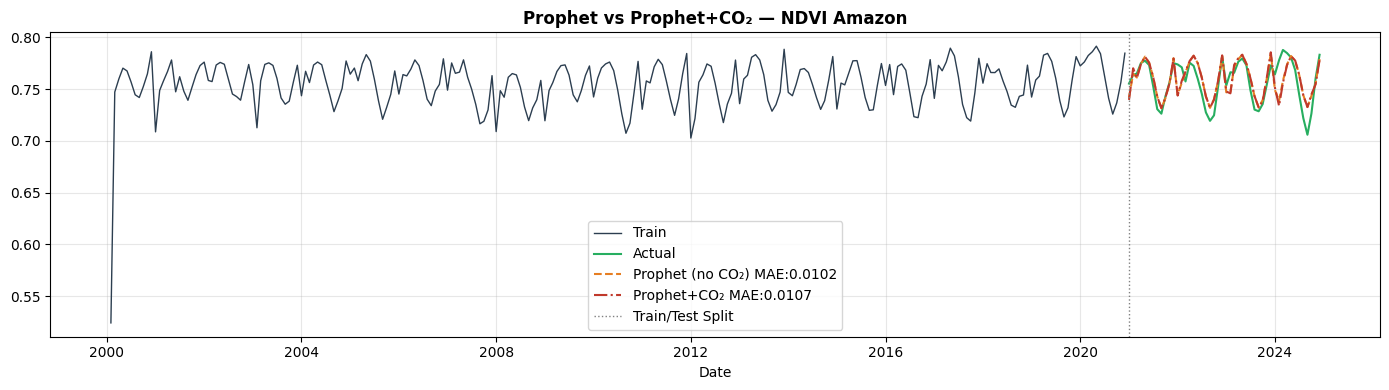

02:36:03 - cmdstanpy - INFO - Chain [1] start processing
02:36:03 - cmdstanpy - INFO - Chain [1] done processing



Fitting Prophet + CO₂ for NDVI Sahel...


02:36:03 - cmdstanpy - INFO - Chain [1] start processing
02:36:03 - cmdstanpy - INFO - Chain [1] done processing


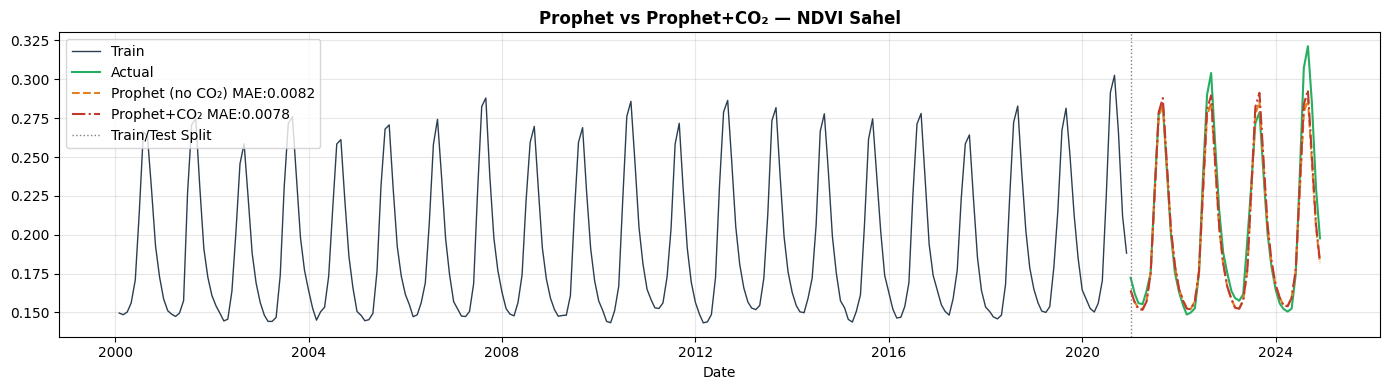

02:36:04 - cmdstanpy - INFO - Chain [1] start processing



Fitting Prophet + CO₂ for SST North Atlantic...


02:36:04 - cmdstanpy - INFO - Chain [1] done processing
02:36:04 - cmdstanpy - INFO - Chain [1] start processing
02:36:04 - cmdstanpy - INFO - Chain [1] done processing


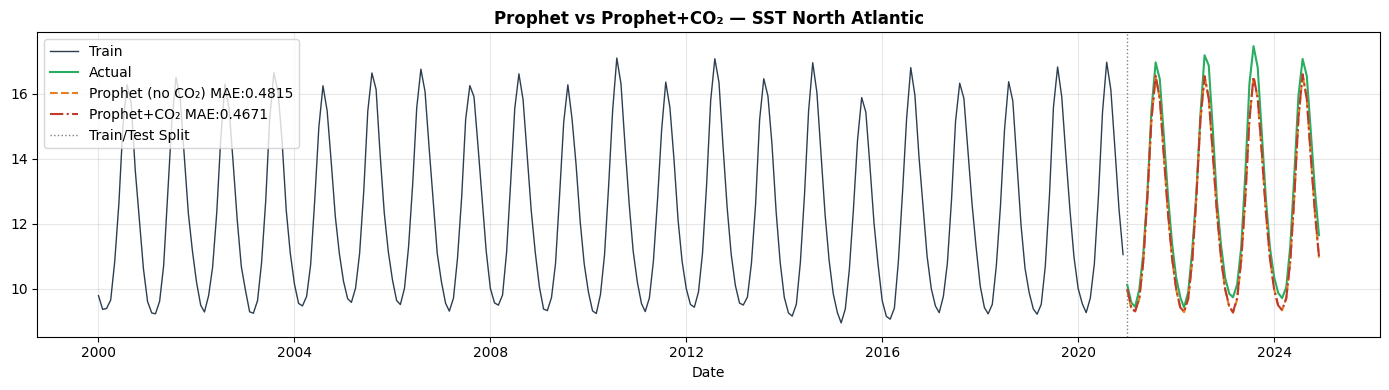

02:36:05 - cmdstanpy - INFO - Chain [1] start processing
02:36:05 - cmdstanpy - INFO - Chain [1] done processing



Fitting Prophet + CO₂ for SST Indian Ocean...


02:36:05 - cmdstanpy - INFO - Chain [1] start processing
02:36:05 - cmdstanpy - INFO - Chain [1] done processing


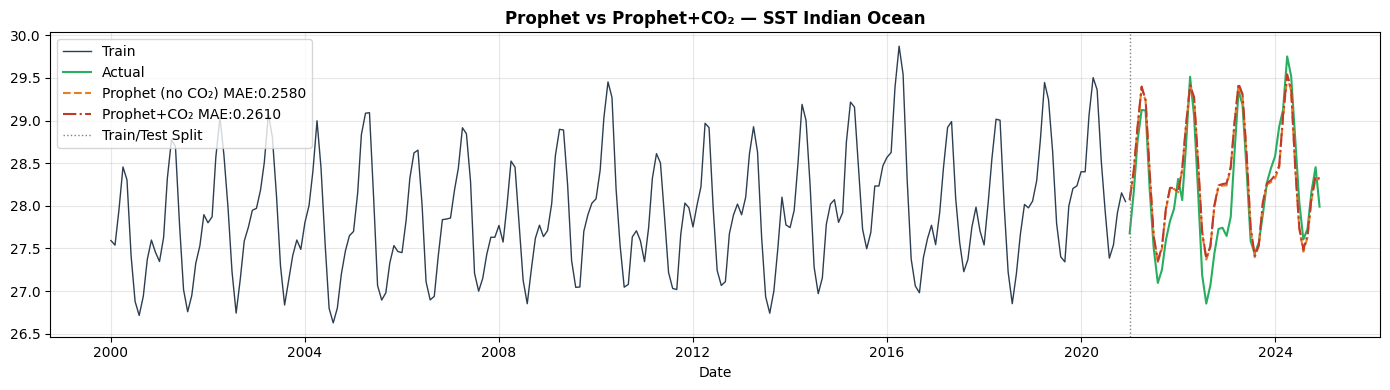


=== Prophet + CO₂ Results ===
            series  Prophet_base_MAE  Prophet_CO2_MAE  change_pct  verdict
       NDVI Amazon            0.0102           0.0107         4.4  ↑ worse
        NDVI Sahel            0.0082           0.0078        -4.7 ↓ better
SST North Atlantic            0.4815           0.4671        -3.0 ↓ better
  SST Indian Ocean            0.2580           0.2610         1.2  ↑ worse


In [3]:
# ============================================================
# Phase B — Prophet + CO₂ as additional regressor
# Prophet supports exogenous variables via add_regressor()
# CO₂ added as a known future regressor (values available
# for both train and test periods)
# Comparison: Prophet best version vs Prophet + CO₂
# Reference: Taylor & Letham (2018) Am. Statistician 72(1)
# ============================================================

from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path

DATA = Path('../data/processed')
FIGURES = Path('../outputs/figures')

# Load CO₂ if not already loaded
co2_train = pd.read_csv(DATA / 'co2_train.csv')
co2_test = pd.read_csv(DATA / 'co2_test.csv')
co2_train['date'] = pd.to_datetime(co2_train['date'])
co2_test['date'] = pd.to_datetime(co2_test['date'])

def prepare_prophet_co2(train, test, value_col, co2_train, co2_test):
    """Merge CO₂ into Prophet format df."""
    # Train
    train_df = train[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'})
    train_df = train_df.merge(
        co2_train.rename(columns={'date': 'ds'}), on='ds', how='inner')

    # Test (future df needs CO₂ values)
    test_df = test[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'})
    test_df = test_df.merge(
        co2_test.rename(columns={'date': 'ds'}), on='ds', how='inner')

    return train_df, test_df

def run_prophet_co2(train, test, value_col, series_name,
                    seasonality_mode='additive'):
    print(f"\nFitting Prophet + CO₂ for {series_name}...")

    train_df, test_df = prepare_prophet_co2(
        train, test, value_col, co2_train, co2_test)

    # Best params from V2/V3 per series
    best_params = {
        'NDVI Amazon':       {'changepoint_prior_scale': 0.01,
                              'seasonality_prior_scale': 20.0},
        'NDVI Sahel':        {'changepoint_prior_scale': 0.01,
                              'seasonality_prior_scale': 1.0},
        'SST North Atlantic':{'changepoint_prior_scale': 0.01,
                              'seasonality_prior_scale': 10.0},
        'SST Indian Ocean':  {'changepoint_prior_scale': 0.01,
                              'seasonality_prior_scale': 1.0}
    }
    params = best_params[series_name]

    model = Prophet(
        changepoint_prior_scale=params['changepoint_prior_scale'],
        seasonality_prior_scale=params['seasonality_prior_scale'],
        seasonality_mode=seasonality_mode,
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_range=0.95
    )

    # Add CO₂ as regressor
    model.add_regressor('co2_mean')
    model.fit(train_df)

    # Future df must include CO₂ values
    future = pd.concat([
        train_df[['ds', 'co2_mean']],
        test_df[['ds', 'co2_mean']]
    ], ignore_index=True)

    forecast = model.predict(future)
    forecast_test = forecast.tail(len(test_df))['yhat'].values
    actual = test_df['y'].values

    mae = mean_absolute_error(actual, forecast_test)
    rmse = np.sqrt(mean_squared_error(actual, forecast_test))

    # Also get baseline Prophet (no CO₂) MAE for comparison
    model_base = Prophet(
        changepoint_prior_scale=params['changepoint_prior_scale'],
        seasonality_prior_scale=params['seasonality_prior_scale'],
        seasonality_mode=seasonality_mode,
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )
    train_base = train_df[['ds', 'y']]
    model_base.fit(train_base)
    future_base = model_base.make_future_dataframe(
        periods=len(test_df), freq='MS')
    fc_base = model_base.predict(future_base)
    fc_base_test = fc_base.tail(len(test_df))['yhat'].values
    mae_base = mean_absolute_error(actual, fc_base_test)

    # Plot
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['date'], train[value_col],
            color='#2c3e50', linewidth=1, label='Train')
    ax.plot(test_df['ds'], actual,
            color='#27ae60', linewidth=1.5, label='Actual')
    ax.plot(test_df['ds'], fc_base_test,
            color='#e67e22', linewidth=1.5, linestyle='--',
            label=f'Prophet (no CO₂) MAE:{mae_base:.4f}')
    ax.plot(test_df['ds'], forecast_test,
            color='#c0392b', linewidth=1.5, linestyle='-.',
            label=f'Prophet+CO₂ MAE:{mae:.4f}')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test Split')
    ax.set_title(f'Prophet vs Prophet+CO₂ — {series_name}',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    filename = f"fig_prophet_co2_{series_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()

    diff = ((mae - mae_base) / mae_base) * 100
    direction = "↓ better" if mae < mae_base else "↑ worse"

    return {
        'series': series_name,
        'Prophet_base_MAE': round(mae_base, 4),
        'Prophet_CO2_MAE': round(mae, 4),
        'change_pct': round(diff, 1),
        'verdict': direction
    }

# NDVI series — multiplicative, SST — additive
results_prophet_co2 = []

results_prophet_co2.append(run_prophet_co2(
    ndvi_amazon_train, ndvi_amazon_test,
    'ndvi_mean', 'NDVI Amazon',
    seasonality_mode='multiplicative'))

results_prophet_co2.append(run_prophet_co2(
    ndvi_sahel_train, ndvi_sahel_test,
    'ndvi_mean', 'NDVI Sahel',
    seasonality_mode='multiplicative'))

results_prophet_co2.append(run_prophet_co2(
    sst_atlantic_train, sst_atlantic_test,
    'sst_mean', 'SST North Atlantic',
    seasonality_mode='additive'))

results_prophet_co2.append(run_prophet_co2(
    sst_indian_train, sst_indian_test,
    'sst_mean', 'SST Indian Ocean',
    seasonality_mode='additive'))

results_prophet_co2_df = pd.DataFrame(results_prophet_co2)
print("\n=== Prophet + CO₂ Results ===")
print(results_prophet_co2_df.to_string(index=False))